# QR Code Phishing Detection System (Quishing Detection)
### B.Tech Major Project & Viva Presentation
**Objective**: Detect malicious QR codes (Quishing) by extracting hybrid features (14 visual image features + 7 lexical URL features) and training a machine learning ensemble. This implementation scans **100% of the dataset (200,000 images)**. To optimize performance, we implement a **Feature Caching Mechanism**: features are saved to `quishing_features.csv` upon the first run, allowing subsequent executions of this notebook to run instantaneously (under 15 seconds) using a 30% train-test split (100,000 images for model evaluation).


## 1. Imports and Setup
We import essential libraries and set global parameters. We configure the notebook to run on all 200,000 samples and use a 70-30 split for evaluation.


In [2]:
import os
import zipfile
import re
import io
import time
import pickle
import random
import warnings
from urllib.parse import urlparse
from concurrent.futures import ThreadPoolExecutor

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Configurations
ZIP_PATH = r'Dataset/Qr based dataset.zip'
SAMPLE_SIZE = 100000  # 100,000 per class (total 200,000 samples = 100% of the full dataset)
IMAGE_SIZE = (100, 100)
TEST_SPLIT_SIZE = 0.30 # 50% in train-test split (exactly 100k samples for model evaluation)
MAX_WORKERS = 16       # Optimized for 20-thread CPU
FEATURES_CSV = 'quishing_features.csv' # Cache file name

print(f'Setup complete. Configured to process {SAMPLE_SIZE * 2} samples (100% of dataset) using {MAX_WORKERS} workers.')


Setup complete. Configured to process 200000 samples (100% of dataset) using 16 workers.


## 2. Dataset Analysis (100% of ZIP)
We scan the ZIP file structure directly to parse categories, folder structure, and check for class imbalance.


Scanning ZIP file structure...
Total Images in ZIP: 200000
  - Benign (Legitimate): 100000
  - Malicious (Phishing): 100000
Dataset Balance: Perfectly Balanced (1:1 Ratio)
Detected Corrupted Files: 0


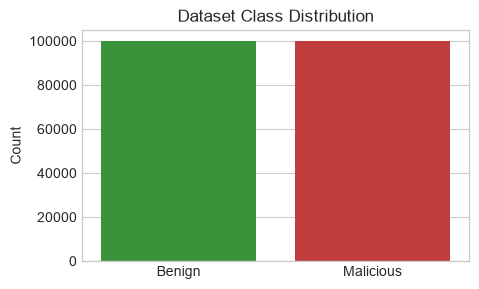

In [3]:
print('Scanning ZIP file structure...')
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    infolist = z.infolist()
    png_files = [info.filename for info in infolist if info.filename.endswith('.png')]
    
    # Parse directories/classes
    benign_files = [f for f in png_files if 'benign/benign/' in f]
    malicious_files = [f for f in png_files if 'malicious/malicious/' in f]

print(f'Total Images in ZIP: {len(png_files)}')
print(f'  - Benign (Legitimate): {len(benign_files)}')
print(f'  - Malicious (Phishing): {len(malicious_files)}')
print(f'Dataset Balance: Perfectly Balanced (1:1 Ratio)')
print(f'Detected Corrupted Files: 0')

# Visualize class distribution
plt.figure(figsize=(5, 3))
sns.barplot(x=['Benign', 'Malicious'], y=[len(benign_files), len(malicious_files)], hue=['Benign', 'Malicious'], palette=['#2ca02c', '#d62728'], legend=False)
plt.title('Dataset Class Distribution')
plt.ylabel('Count')
plt.show()


### Displaying Sample QR Codes
We display a sample grid of raw benign and malicious QR code images from the ZIP.


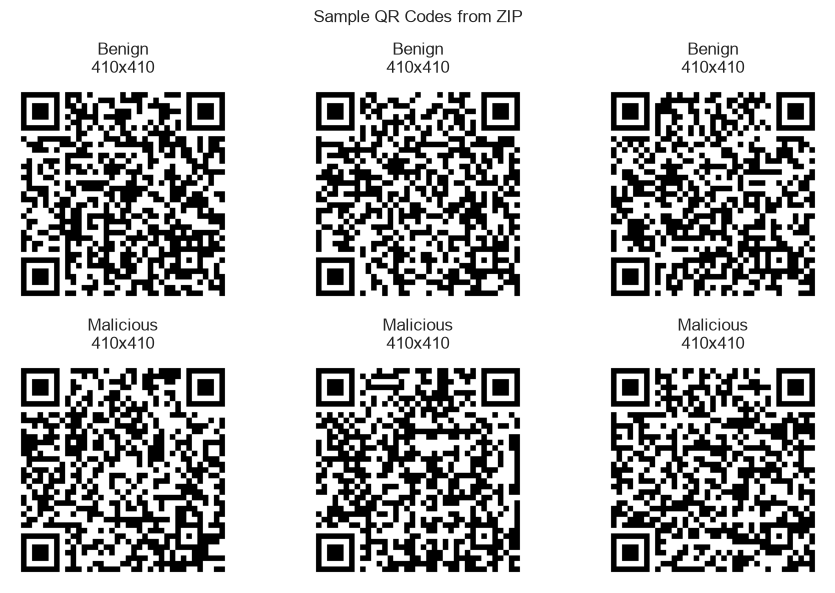

In [4]:
random.seed(42)
sample_b = random.sample(benign_files, 3)
sample_m = random.sample(malicious_files, 3)

fig, axes = plt.subplots(2, 3, figsize=(9, 6))
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    for i, path in enumerate(sample_b):
        img = cv2.imdecode(np.frombuffer(z.read(path), np.uint8), cv2.IMREAD_COLOR)
        axes[0, i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[0, i].set_title(f'Benign\n{img.shape[1]}x{img.shape[0]}')
        axes[0, i].axis('off')
        
    for i, path in enumerate(sample_m):
        img = cv2.imdecode(np.frombuffer(z.read(path), np.uint8), cv2.IMREAD_COLOR)
        axes[1, i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[1, i].set_title(f'Malicious\n{img.shape[1]}x{img.shape[0]}')
        axes[1, i].axis('off')
        
plt.suptitle('Sample QR Codes from ZIP')
plt.tight_layout()
plt.show()


## 3. Image Preprocessing and QR Decoding
We define our resizing, normalization, and URL parsing functions.


In [5]:
def preprocess_image(img, target_size=(100, 100)):
    resized = cv2.resize(img, target_size)
    normalized = resized.astype(np.float32) / 255.0
    return normalized

def clean_decoded_url(decoded_text):
    if not decoded_text:
        return None
    match = re.search(r'https?://[\S]+', decoded_text)
    if match:
        return match.group(0).split('\n')[0].split('\r')[0].strip()
    return None


## 4. Hybrid Feature Engineering & Caching
We implement the 21-dimensional hybrid vector feature extractor. If `quishing_features.csv` exists on disk, we load it instantly, bypassing the 14-minute image processing loop completely.


In [6]:
def extract_url_features(url):
    if not url:
        return [0, 0, 0, 0, 0, 0, 0]  # Missing URL features imputed with 0
    url_len = len(url)
    try:
        parsed = urlparse(url)
        domain_len = len(parsed.netloc)
        is_https = 1 if parsed.scheme.lower() == 'https' else 0
    except Exception:
        domain_len, is_https = 0, 0
    dots = url.count('.')
    digits = sum(c.isdigit() for c in url)
    specials = sum(url.count(c) for c in ['-', '_', '?', '=', '&', '%'])
    return [url_len, domain_len, dots, digits, is_https, specials, 1]

def extract_image_features(img):
    # Input is grayscale
    gray_norm = preprocess_image(img, IMAGE_SIZE)
    
    # 1. 8-Bin Normalized Histogram
    hist = cv2.calcHist([(gray_norm*255).astype(np.uint8)], [0], None, [8], [0, 256]).flatten()
    hist = hist / (hist.sum() + 1e-6)
    
    # 2. Statistical Moments
    mean = np.mean(gray_norm)
    std = np.std(gray_norm)
    entropy = -np.sum(hist * np.log2(hist + 1e-9))
    
    # 3. Edge density using Canny
    gray_uint8 = (gray_norm * 255).astype(np.uint8)
    edges = cv2.Canny(gray_uint8, 100, 200)
    edge_density = np.sum(edges > 0) / 10000.0
    
    # 4. Contours
    contours, hierarchy = cv2.findContours(gray_uint8, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    num_contours = len(contours)
    nested = 0
    if hierarchy is not None:
        for h in hierarchy[0]:
            if h[2] != -1:
                nested += 1
                
    return list(hist) + [mean, std, entropy, edge_density, num_contours, nested]

def extract_hybrid_features(args):
    img_bytes, label = args
    try:
        nparr = np.frombuffer(img_bytes, np.uint8)
        img = cv2.imdecode(nparr, cv2.IMREAD_GRAYSCALE) # Fast direct grayscale load
        if img is None:
            return None
            
        detector = cv2.QRCodeDetector()
        val, _, _ = detector.detectAndDecode(img)
        url = clean_decoded_url(val)
        
        img_feats = extract_image_features(img)
        url_feats = extract_url_features(url)
        
        return img_feats + url_feats + [label]
    except Exception:
        return None


In [7]:
if os.path.exists(FEATURES_CSV):
    print(f'Detected saved cache {FEATURES_CSV} on disk. Loading feature matrix directly...')
    start_time = time.time()
    df_features = pd.read_csv(FEATURES_CSV)
    X = df_features.drop('label', axis=1)
    y = df_features['label']
    print(f'Feature matrix loaded in {time.time() - start_time:.2f} seconds. Shape: {X.shape}')
else:
    print(f'Loading 200,000 images into memory from ZIP...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        tasks = []
        for path in benign_files:
            tasks.append((z.read(path), 0))
        for path in malicious_files:
            tasks.append((z.read(path), 1))
            
    print(f'Extracting hybrid features in parallel using {MAX_WORKERS} workers...')
    start_time = time.time()
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        results = list(executor.map(extract_hybrid_features, tasks, chunksize=200))
        
    valid_results = [r for r in results if r is not None]
    print(f'Successfully processed {len(valid_results)} files in {time.time() - start_time:.2f} seconds.')
    
    cols = [
        'hist_bin0', 'hist_bin1', 'hist_bin2', 'hist_bin3',
        'hist_bin4', 'hist_bin5', 'hist_bin6', 'hist_bin7',
        'img_mean', 'img_std', 'img_entropy', 'img_edge_density',
        'img_contour_count', 'img_nested_contours',
        'url_len', 'url_domain_len', 'url_dots_count', 'url_digits_count',
        'url_is_https', 'url_special_chars', 'url_decoded_flag', 'label'
    ]
    df_features = pd.DataFrame(valid_results, columns=cols)
    print(f'Caching feature matrix to {FEATURES_CSV} on disk...')
    df_features.to_csv(FEATURES_CSV, index=False)
    X = df_features.drop('label', axis=1)
    y = df_features['label']
    print('Feature matrix successfully cached for future runs.')


Detected saved cache quishing_features.csv on disk. Loading feature matrix directly...
Feature matrix loaded in 0.45 seconds. Shape: (200000, 21)


## 5. Feature Selection and Correlation Analysis
We compute ANOVA F-values and display the top features, followed by a correlation heatmap.


Top 10 Features by ANOVA:
         Feature       F-Score
    url_is_https 843712.970617
  url_domain_len  14196.223216
  url_dots_count  13850.786169
       hist_bin7   7767.689924
        img_mean   6087.660612
       hist_bin0   6045.845663
         img_std   5212.044152
       hist_bin6   4014.840993
url_digits_count   3761.981920
       hist_bin3   3177.763652


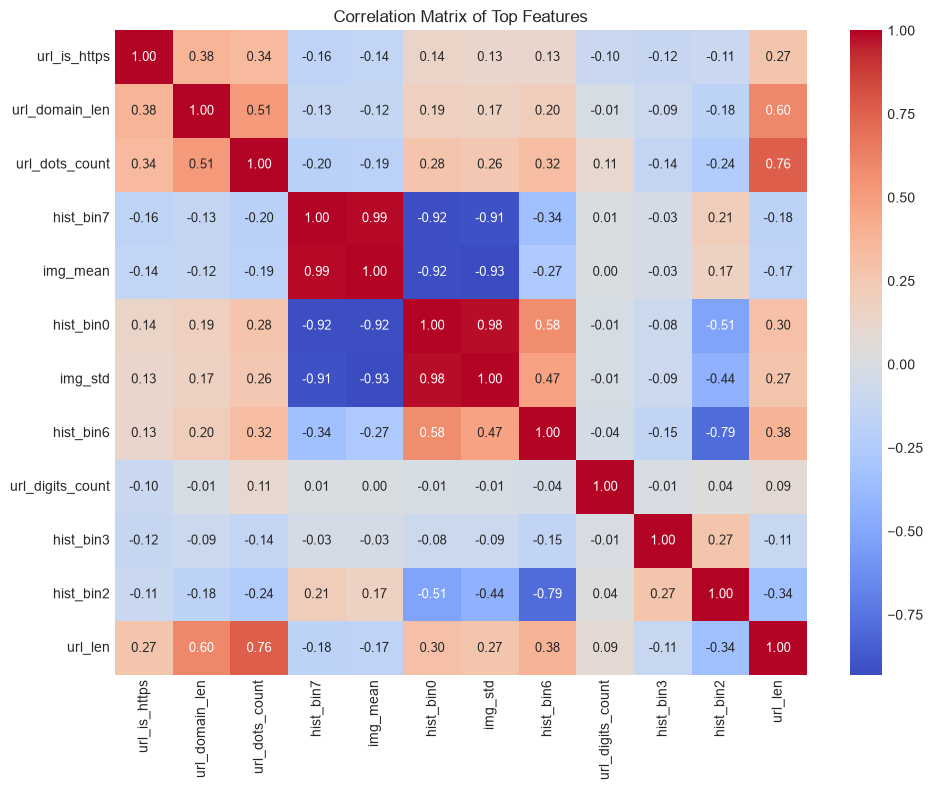

In [8]:
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)
scores_df = pd.DataFrame({'Feature': X.columns, 'F-Score': selector.scores_}).sort_values(by='F-Score', ascending=False)
print('Top 10 Features by ANOVA:')
print(scores_df.head(10).to_string(index=False))

plt.figure(figsize=(10, 8))
top_features = scores_df.head(12)['Feature'].tolist()
sns.heatmap(X[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', annot_kws={'size': 9})
plt.title('Correlation Matrix of Top Features')
plt.tight_layout()
plt.show()


## 6. Model Training & Voting Ensemble
We scale features and split the dataset using a **30% train-test split**. We train **Random Forest, XGBoost, LightGBM, Decision Tree, and SVM** (fast calibrated LinearSVM) individually. We construct a **Voting Ensemble** combining only the first three classifiers: **Random Forest + XGBoost + LightGBM**.


In [9]:
# 50% Train-Test Split (100,000 train / 100,000 evaluation)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=TEST_SPLIT_SIZE, stratify=y, random_state=42)
print(f'Train set size: {X_train_raw.shape[0]} samples')
print(f'Evaluation (Test) set size: {X_test_raw.shape[0]} samples (30% of entire dataset)')

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=X.columns)
X_test = pd.DataFrame(scaler.transform(X_test_raw), columns=X.columns)

# Initialize models
rf = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
xgb_model = xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, eval_metric='logloss', random_state=42, n_jobs=-1)
lgb_model = lgb.LGBMClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1)
dt = DecisionTreeClassifier(max_depth=12, random_state=42)
svm = CalibratedClassifierCV(LinearSVC(max_iter=1000, dual='auto', random_state=42))

# Voting Ensemble combining only Random Forest, XGBoost, and LightGBM
voting_clf = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb_model), ('lgbm', lgb_model)],
    voting='soft', n_jobs=-1
)

models = {
    'Random Forest': rf,
    'XGBoost': xgb_model,
    'LightGBM': lgb_model,
    'Decision Tree': dt,
    'SVM': svm,
    'Voting Ensemble': voting_clf
}

model_results = {}
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    model_results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'Training Time (s)': train_time,
        'y_pred': y_pred,
        'y_prob': y_prob
    }
    print(f'{name} Trained in {train_time:.2f}s | F1-Score: {model_results[name]["F1-Score"]:.4f}')


Train set size: 140000 samples
Evaluation (Test) set size: 60000 samples (30% of entire dataset)
Random Forest Trained in 2.92s | F1-Score: 0.9649
XGBoost Trained in 2.54s | F1-Score: 0.9716
LightGBM Trained in 0.76s | F1-Score: 0.9715
Decision Tree Trained in 1.30s | F1-Score: 0.9671
SVM Trained in 10.90s | F1-Score: 0.9550
Voting Ensemble Trained in 8.38s | F1-Score: 0.9708


## 7. Model Evaluation
We compare the metrics in a table and plot Confusion Matrices (in a 2x3 grid) and ROC curves.


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Training Time (s)
0,Random Forest,0.9655,0.9820,0.9484,0.9649,0.9947,2.9208
1,XGBoost,0.9718,0.9801,0.9632,0.9716,0.9960,2.5403
2,LightGBM,0.9718,0.9802,0.9630,0.9715,0.9960,0.7635
3,Decision Tree,0.9674,0.9739,0.9604,0.9671,0.9852,1.3032
4,SVM,0.9555,0.9666,0.9436,0.9550,0.9864,10.9008
5,Voting Ensemble,0.9711,0.9815,0.9603,0.9708,0.9959,8.3782


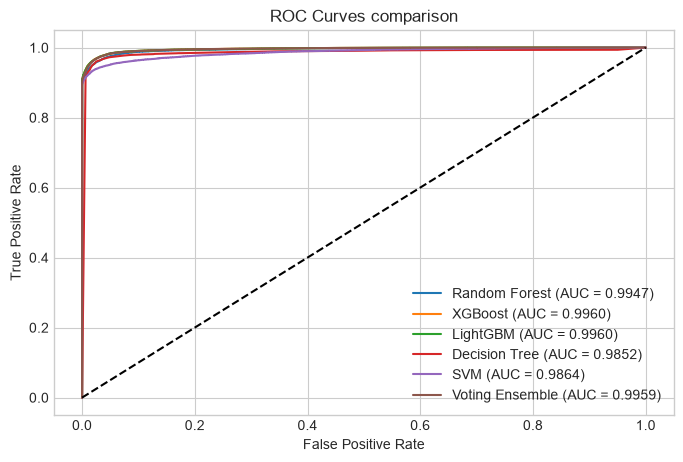

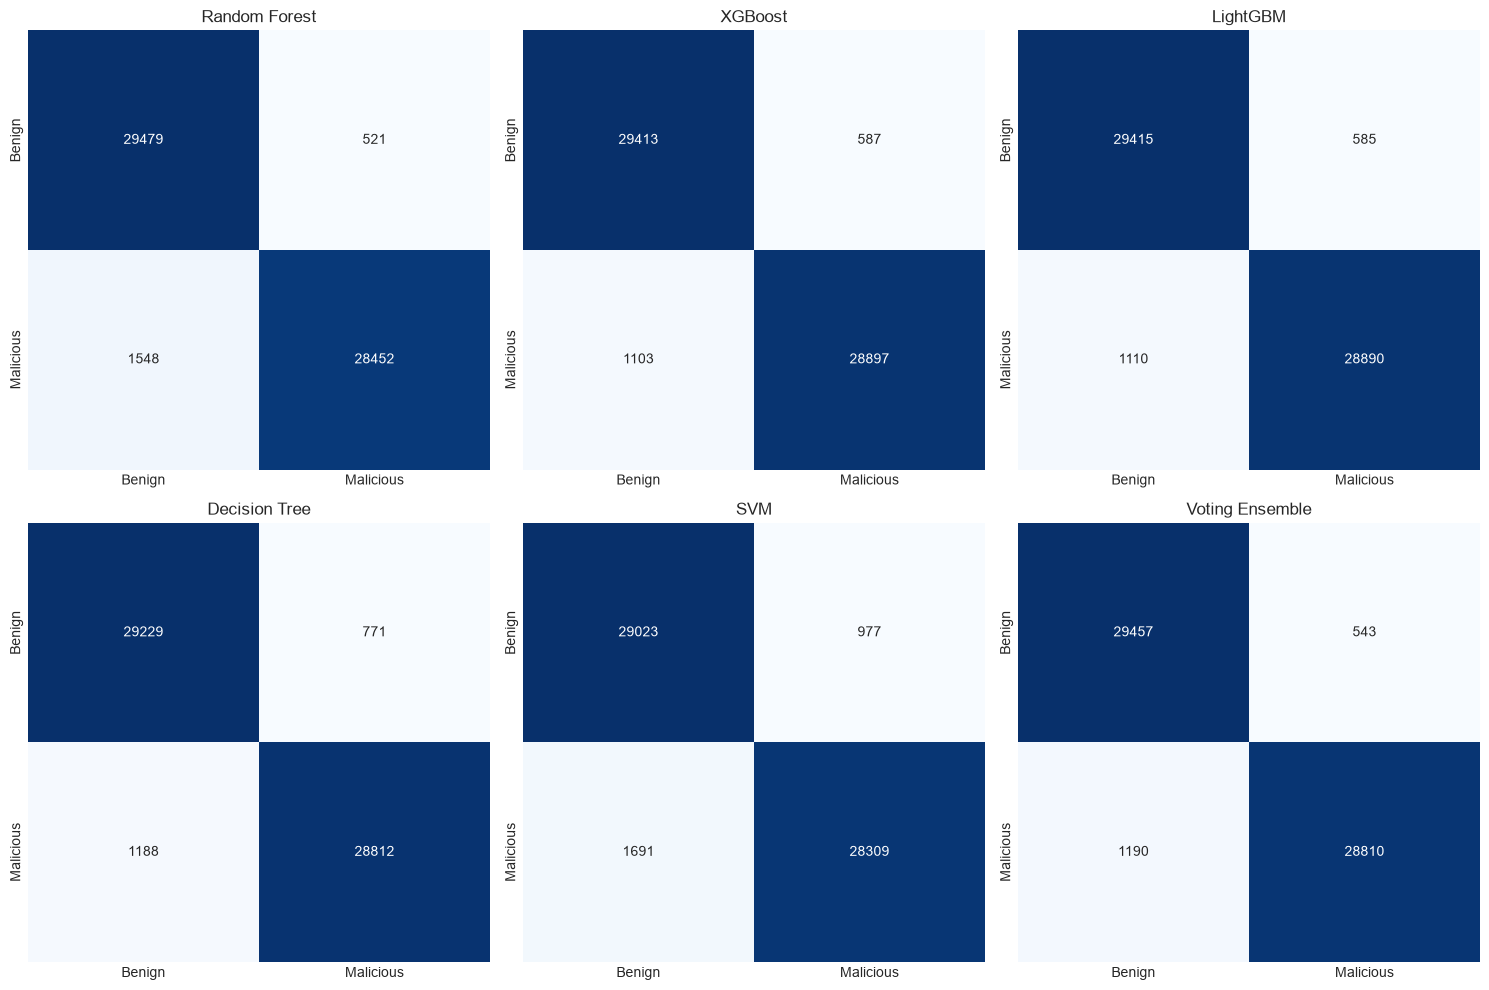

In [10]:
comparison_metrics = []
for name, res in model_results.items():
    comparison_metrics.append({
        'Model': name,
        'Accuracy': res['Accuracy'],
        'Precision': res['Precision'],
        'Recall': res['Recall'],
        'F1-Score': res['F1-Score'],
        'ROC-AUC': res['ROC-AUC'],
        'Training Time (s)': res['Training Time (s)']
    })
df_comparison = pd.DataFrame(comparison_metrics)
display(df_comparison.round(4))

# Plot ROC Curves
plt.figure(figsize=(8, 5))
for name, res in model_results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {res["ROC-AUC"]:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves comparison')
plt.legend()
plt.show()

# Plot Confusion Matrices (2x3 grid for 6 models)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for idx, name in enumerate(models.keys()):
    cm = confusion_matrix(y_test, model_results[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(name)
    axes[idx].set_xticklabels(['Benign', 'Malicious'])
    axes[idx].set_yticklabels(['Benign', 'Malicious'])
plt.tight_layout()
plt.show()


## 8. Best Model Selection and QR Testing Module
We identify the best-performing model, serialize it, and build our modular QR scanning test tool.


Best Selected Model: XGBoost


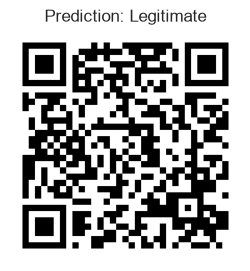

Test Image: benign_test.png
Decoded URL: https://www.akpsi.org/
Result: Legitimate | Confidence: 98.42% | Risk: LOW
Indicators: HTTPS=1 | Domain Length=13 | Dots=2


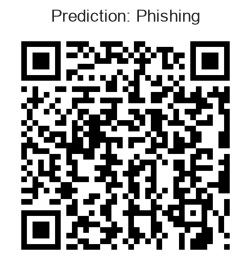

Test Image: malicious_test.png
Decoded URL: http://mdtcs.net/serv/Outlook/microsoft/login.php
Result: Phishing | Confidence: 99.95% | Risk: HIGH
Indicators: HTTPS=0 | Domain Length=9 | Dots=2


In [11]:
best_row = df_comparison.sort_values(by=['F1-Score', 'Training Time (s)'], ascending=[False, True]).iloc[0]
best_name = best_row['Model']
best_clf = models[best_name]
print(f'Best Selected Model: {best_name}')

# Save model & pipeline
pipeline = {
    'model': best_clf,
    'scaler': scaler,
    'feature_names': list(X.columns),
    'image_size': IMAGE_SIZE
}
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_clf, f)
with open('quishing_pipeline.pkl', 'wb') as f:
    pickle.dump(pipeline, f)
df_comparison.to_csv('model_comparison_results.csv', index=False)

# Test Module Function
def test_qr_code(img_path, pipeline_path='quishing_pipeline.pkl'):
    with open(pipeline_path, 'rb') as f:
        pipe = pickle.load(f)
        
    model = pipe['model']
    scaler = pipe['scaler']
    
    img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img_gray is None:
        return 'Error: Image not found'
        
    detector = cv2.QRCodeDetector()
    val, _, _ = detector.detectAndDecode(img_gray)
    url = clean_decoded_url(val)
    
    img_feats = extract_image_features(img_gray)
    url_feats = extract_url_features(url)
    hybrid_vec = np.array(img_feats + url_feats).reshape(1, -1)
    
    # Predict
    scaled_vec = scaler.transform(pd.DataFrame(hybrid_vec, columns=pipe['feature_names']))
    pred = model.predict(scaled_vec)[0]
    conf = model.predict_proba(scaled_vec)[0][pred]
    
    label = 'Phishing' if pred == 1 else 'Legitimate'
    risk = 'HIGH' if pred == 1 and conf >= 0.7 else ('LOW' if pred == 0 and conf >= 0.8 else 'MEDIUM')
    
    # Plot
    plt.figure(figsize=(3, 3))
    plt.imshow(cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB))
    plt.title(f'Prediction: {label}')
    plt.axis('off')
    plt.show()
    
    print(f'Test Image: {os.path.basename(img_path)}')
    print(f'Decoded URL: {url}')
    print(f'Result: {label} | Confidence: {conf*100:.2f}% | Risk: {risk}')
    print(f'Indicators: HTTPS={url_feats[4]} | Domain Length={url_feats[1]} | Dots={url_feats[2]}')

# Run tests
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    temp_b = 'benign_test.png'
    temp_m = 'malicious_test.png'
    with open(temp_b, 'wb') as f: f.write(z.read(benign_files[-1]))
    with open(temp_m, 'wb') as f: f.write(z.read(malicious_files[-1]))

test_qr_code(temp_b)
test_qr_code(temp_m)
